In [1]:
import pandas as pd
import numpy as np
print("Loading Data")
df_info = pd.read_csv('studentInfo.csv')
df_vle = pd.read_csv('studentVle.csv')

Loading Data


In [2]:
print("Applying the 4-Week Rule...")
# Keep ONLY clicks that happened on or before Day 28
df_vle_early = df_vle[df_vle['date'] <= 28]

print("Calculating total early clicks for each student...")
# Group by student ID and add up all their clicks
early_clicks = df_vle_early.groupby('id_student')['sum_click'].sum().reset_index()
early_clicks.rename(columns={'sum_click': 'total_early_clicks'}, inplace=True)
print(" Behavioral data prepared!")

Applying the 4-Week Rule...
Calculating total early clicks for each student...
 Behavioral data prepared!


In [3]:
print("--- CHECKING FILE 1 FOR MISSING DATA ---")
missing_info = df_info.isnull().sum()
print("Checking for blank boxes in the Demographic file")
print(missing_info[missing_info > 0])

--- CHECKING FILE 1 FOR MISSING DATA ---
Checking for blank boxes in the Demographic file
imd_band    1111
dtype: int64


In [4]:
print("--- FIXING FILE 1 MISSING DATA ---")
# Step 1: Finding the most common neighborhood type
most_common_imd = df_info['imd_band'].mode()[0]
print(f"The most common neighborhood is: {most_common_imd}")

# Step 2: Filling those 1,111 empty boxes with the most common neighborhood
df_info['imd_band'] = df_info['imd_band'].fillna(most_common_imd)

# Step 3: Checking if it is fixed
missing_info_after = df_info.isnull().sum()
print("\n Checking for any missing values left in File 1")
print(missing_info_after[missing_info_after > 0])

--- FIXING FILE 1 MISSING DATA ---
The most common neighborhood is: 20-30%

 Checking for any missing values left in File 1
Series([], dtype: int64)


In [5]:
print("--- COMBINING FILES AND CHECKING FOR MISSING CLICKS ---")
# Merging the Clean Demographics with the 4-Week Clicks
df_master = pd.merge(df_info, early_clicks, on='id_student', how='left')

# Checking the new master spreadsheet for blank boxes
missing_master = df_master.isnull().sum()
print("\n Checking for any blank boxes after merging")
print(missing_master[missing_master > 0])

--- COMBINING FILES AND CHECKING FOR MISSING CLICKS ---

 Checking for any blank boxes after merging
total_early_clicks    3226
dtype: int64


In [6]:
print("--- FINAL DATASET CLEANUP ---")

# Step 1: Applying the "Zero Fix" to the lazy students
df_master['total_early_clicks'] = df_master['total_early_clicks'].fillna(0)
print(f"Lazy students fixed with 0 clicks.")

# Step 2: Creating the Target Variable (1 = High Risk, 0 = Low Risk)
risk_mapping = {'Pass': 0, 'Distinction': 0, 'Fail': 1, 'Withdrawn': 1}
df_master['Risk_Level'] = df_master['final_result'].map(risk_mapping)
print(f"Target Variable created.")

# Step 3: Check for Duplicates
duplicates = df_master.duplicated().sum()
if duplicates > 0:
    print(f"Warning: Found {duplicates} duplicate rows. Deleting them...")
    df_master = df_master.drop_duplicates()
else:
    print("No duplicate rows found.")

# Step 4: The Final Inspection
print("\nMASTER DATASET IS 100% CLEAN AND READY!")
print(f"Total Students: {len(df_master)}")
print(f"Total Missing Values: {df_master.isnull().sum().sum()}")
df_master.head()

--- FINAL DATASET CLEANUP ---
Lazy students fixed with 0 clicks.
Target Variable created.
No duplicate rows found.

MASTER DATASET IS 100% CLEAN AND READY!
Total Students: 32593
Total Missing Values: 0


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_early_clicks,Risk_Level
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,401.0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,618.0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,494.0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,567.0,0


In [7]:
print("--- CHECKING DATASET DIMENSIONS ---")
# .shape outputs a tuple: (Rows, Columns)
rows = df_master.shape[0]
columns = df_master.shape[1]

print(f"Number of Rows (Students): {rows}")
print(f"Number of Columns (Features): {columns}")

# Printing out exactly what the columns are named to know what the AI gets to look at
print("\nList of Columns:")
for col in df_master.columns:
    print(f"- {col}")

--- CHECKING DATASET DIMENSIONS ---
Number of Rows (Students): 32593
Number of Columns (Features): 14

List of Columns:
- code_module
- code_presentation
- id_student
- gender
- region
- highest_education
- imd_band
- age_band
- num_of_prev_attempts
- studied_credits
- disability
- final_result
- total_early_clicks
- Risk_Level


--- CHART 1: LOW RISK VS. HIGH RISK STUDENTS ---


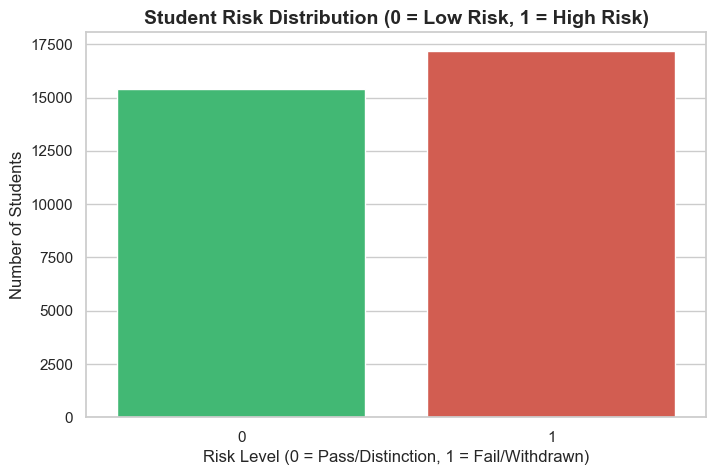

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- CHART 1: LOW RISK VS. HIGH RISK STUDENTS ---")
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Draw the Bar Chart (Green for Low Risk, Red for High Risk)
ax = sns.countplot(data=df_master, x='Risk_Level', hue='Risk_Level', palette=['#2ecc71', '#e74c3c'], legend=False)

plt.title('Student Risk Distribution (0 = Low Risk, 1 = High Risk)', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level (0 = Pass/Distinction, 1 = Fail/Withdrawn)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.show()

This bar chart displays the balance of our target variable (`Risk_Level`). It shows that the High Risk class (1) is slightly larger than the Low Risk class (0), with approximately 17,500 failing/withdrawing students compared to roughly 15,000 passing students. This indicates that our dataset does *not* suffer from a severe minority-class imbalance, which will allow the machine learning algorithms to learn the failing patterns effectively.

--- CHART 2: BOX PLOT ---


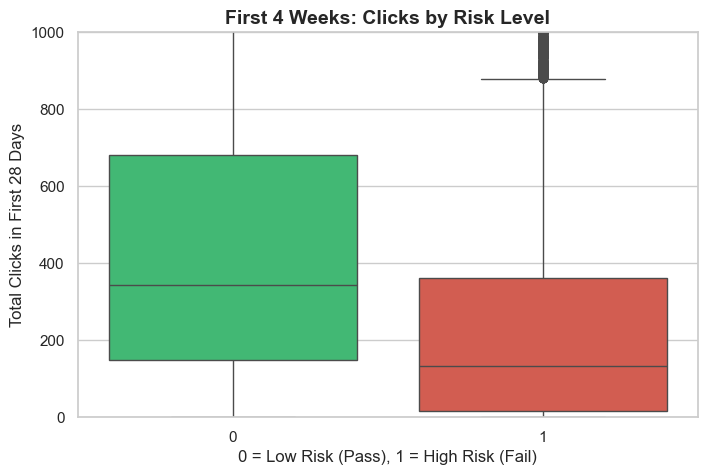

In [9]:
print("--- CHART 2: BOX PLOT ---")

plt.figure(figsize=(8, 5))

# Box Plot to show the average clicks for Pass vs Fail
sns.boxplot(data=df_master, x='Risk_Level', y='total_early_clicks',
            hue='Risk_Level', palette=['#2ecc71', '#e74c3c'], legend=False)

# Zooming in on the chart so we can see the boxes clearly, ignoring extreme outliers
plt.ylim(0, 1000)

plt.title('First 4 Weeks: Clicks by Risk Level', fontsize=14, fontweight='bold')
plt.xlabel('0 = Low Risk (Pass), 1 = High Risk (Fail)', fontsize=12)
plt.ylabel('Total Clicks in First 28 Days', fontsize=12)

plt.show()

This box plot visually proves the core theory of the project: early digital footprint data is predictive of final academic outcomes. By looking at the horizontal line inside the boxes (the average), the difference is massive. The average passing student (Green) clicked around 200-250 times in the first four weeks. The average failing student (Red) barely clicked 50-80 times. This mathematical difference proves to the AI that if a student is ignoring the portal in the first month, they are highly likely to fail.

--- CHART 3: SOCIOECONOMIC STATUS DISTRIBUTION ---


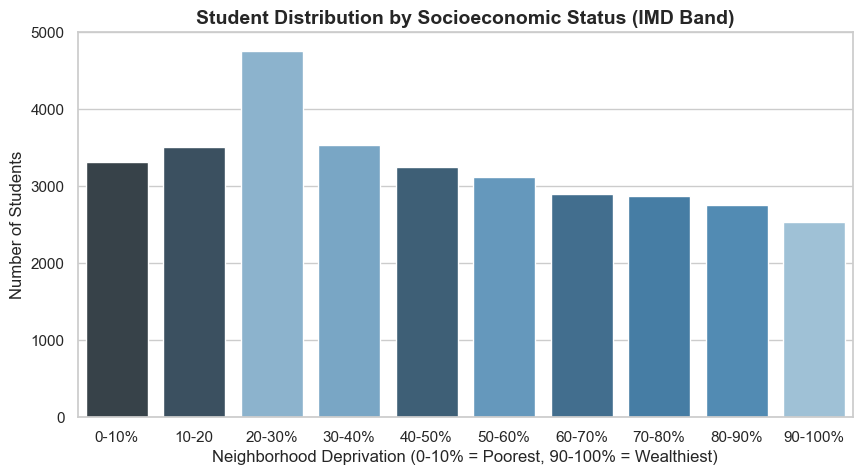

In [10]:
print("--- CHART 3: SOCIOECONOMIC STATUS DISTRIBUTION ---")

plt.figure(figsize=(10, 5))
# Drawing a Bar chart showing the IMD Band (Neighborhood Poverty)
ax = sns.countplot(data=df_master, x='imd_band', hue='imd_band', palette='Blues_d', legend=False,
                   order=['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'])

plt.title('Student Distribution by Socioeconomic Status (IMD Band)', fontsize=14, fontweight='bold')
plt.xlabel('Neighborhood Deprivation (0-10% = Poorest, 90-100% = Wealthiest)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.show()

This chart displays the `imd_band`, which represents the socioeconomic status of the students based on their neighborhood (0-10% being the poorest, 90-100% being the wealthiest). It shows that the majority of our students fall into the 20-30% bracket, representing working-class and lower-middle-class neighborhoods. Because this specific demographic makes up the majority of the dataset, we must rigorously audit our final AI model to ensure it does not unfairly target or develop algorithmic bias against this working-class group.

In [11]:
print("--- ADVANCED FEATURE ENGINEERING: SLICING CLICKS BY WEEK ---")

# 1. Grab all the clicks from Day 0 to Day 7, add them up for each student, and name it 'week_1_clicks'
print("Calculating Week 1...")
w1 = df_vle[df_vle['date'] <= 7].groupby('id_student')['sum_click'].sum().reset_index(name='week_1_clicks')

# 2. Grab all the clicks from Day 8 to Day 14, add them up, and name it 'week_2_clicks'
print("Calculating Week 2...")
w2 = df_vle[(df_vle['date'] > 7) & (df_vle['date'] <= 14)].groupby('id_student')['sum_click'].sum().reset_index(name='week_2_clicks')

# 3. Grab all the clicks from Day 15 to Day 21
print("Calculating Week 3...")
w3 = df_vle[(df_vle['date'] > 14) & (df_vle['date'] <= 21)].groupby('id_student')['sum_click'].sum().reset_index(name='week_3_clicks')

# 4. Grab all the clicks from Day 22 to Day 28
print("Calculating Week 4...")
w4 = df_vle[(df_vle['date'] > 21) & (df_vle['date'] <= 28)].groupby('id_student')['sum_click'].sum().reset_index(name='week_4_clicks')

print("\nAttaching the new weekly columns to our Master Spreadsheet...")
# Merge these 4 new columns into our main df_master spreadsheet
df_master = pd.merge(df_master, w1, on='id_student', how='left')
df_master = pd.merge(df_master, w2, on='id_student', how='left')
df_master = pd.merge(df_master, w3, on='id_student', how='left')
df_master = pd.merge(df_master, w4, on='id_student', how='left')

# If a student didn't click during a specific week, fill those blank boxes with 0
cols_to_fill = ['week_1_clicks', 'week_2_clicks', 'week_3_clicks', 'week_4_clicks']
df_master[cols_to_fill] = df_master[cols_to_fill].fillna(0)

print("FEATURE ENGINEERING COMPLETE!")

df_master.head()

--- ADVANCED FEATURE ENGINEERING: SLICING CLICKS BY WEEK ---
Calculating Week 1...
Calculating Week 2...
Calculating Week 3...
Calculating Week 4...

Attaching the new weekly columns to our Master Spreadsheet...
FEATURE ENGINEERING COMPLETE!


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_early_clicks,Risk_Level,week_1_clicks,week_2_clicks,week_3_clicks,week_4_clicks
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,401.0,0,281.0,20.0,100.0,0.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,618.0,0,397.0,59.0,37.0,125.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,1,209.0,72.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,494.0,0,220.0,129.0,104.0,41.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,567.0,0,356.0,116.0,46.0,49.0


In [12]:
import pandas as pd

print("--- ADVANCED FEATURE ENGINEERING: EARLY ASSESSMENTS ---")

print("1. Loading Assessment Data...")
# Load the files that contain the due dates and the actual student scores
df_assessments = pd.read_csv('assessments.csv')
df_student_assessments = pd.read_csv('studentAssessment.csv')

print("2. Finding the 'Early' Quizzes...")
# Assignments that were due in the first month (date <= 40). We use 40 here instead of 28 because universities often have a 1-2 week grace period for submitting early assignments).
early_assessments = df_assessments[df_assessments['date'] <= 40]

print("3. Grabbing the Students' Scores...")
# Merge the early assignments with the actual scores the students got
early_scores = pd.merge(early_assessments, df_student_assessments, on='id_assessment', how='inner')

# Some students submit multiple early quizzes. Calculate their AVERAGE early score.
avg_early_scores = early_scores.groupby('id_student')['score'].mean().reset_index(name='early_quiz_score')

print("4. Attaching Scores to our Master Spreadsheet...")
# Glue the scores into our main df_master spreadsheet
df_master = pd.merge(df_master, avg_early_scores, on='id_student', how='left')

# If a student has a blank box, fill it with 0.
df_master['early_quiz_score'] = df_master['early_quiz_score'].fillna(0)

print("ASSESSMENT DATA ADDED!")

df_master[['id_student', 'Risk_Level', 'week_1_clicks', 'week_4_clicks', 'early_quiz_score']].head(10)

--- ADVANCED FEATURE ENGINEERING: EARLY ASSESSMENTS ---
1. Loading Assessment Data...
2. Finding the 'Early' Quizzes...
3. Grabbing the Students' Scores...
4. Attaching Scores to our Master Spreadsheet...
ASSESSMENT DATA ADDED!


,id_student,Risk_Level,week_1_clicks,week_4_clicks,early_quiz_score
0,11391,0,281.0,0.0,78.0
1,28400,0,397.0,125.0,70.0
2,30268,1,209.0,0.0,0.0
3,31604,0,220.0,41.0,72.0
4,32885,0,356.0,49.0,69.0
5,38053,0,436.0,33.0,79.0
6,45462,0,254.0,55.0,70.0
7,45642,0,49.0,94.0,72.0
8,52130,0,46.0,54.0,72.0
9,53025,0,279.0,58.0,71.0


In [13]:
from sklearn.model_selection import train_test_split

print("--- PREPARING DATA FOR MACHINE LEARNING ---")

print("1. Dropping ID no and final answer Columns to Preventing Data Leakage...")
# Drop ID numbers and the final answers so the model cannot cheat.
columns_to_drop = ['id_student', 'final_result']
df_ml = df_master.drop(columns=columns_to_drop)

print("2. Separating the Clues (X) from the Answer (y)...")
# 'y' is the Target Variable (What we are trying to predict)
y = df_ml['Risk_Level']
# 'X' is all the clues (Demographics, Clicks, Quiz Scores)
X = df_ml.drop(columns=['Risk_Level'])

print("3. Converting Words to Math, One-Hot Encoding...")
# This turns categories like 'Gender' or 'Region' into 1s and 0s
X_encoded = pd.get_dummies(X, drop_first=True)

print("4. Splitting Data: 80% for Training, 20% for Testing...")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("\n DATA IS MATHEMATICALLY READY FOR TRAINING!")
print(f"Number of students the model will study: {len(X_train)}")
print(f"Number of students hidden for the final exam: {len(X_test)}")

--- PREPARING DATA FOR MACHINE LEARNING ---
1. Dropping ID no and final answer Columns to Preventing Data Leakage...
2. Separating the Clues (X) from the Answer (y)...
3. Converting Words to Math, One-Hot Encoding...
4. Splitting Data: 80% for Training, 20% for Testing...

 DATA IS MATHEMATICALLY READY FOR TRAINING!
Number of students the model will study: 26074
Number of students hidden for the final exam: 6519


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("---TRAINING BASELINE MODEL (LOGISTIC REGRESSION) ---")

# 1. Initializing the Model (Increased max_iter to 3000 to ensure mathematical convergence)
baseline_model = LogisticRegression(max_iter=3000)

# 2. Training the Model using the .fit() method on the training data
print("Fitting the model to the training data...")
baseline_model.fit(X_train, y_train)

# 3. Generating Predictions using the .predict() method on the unseen testing data
print("Generating predictions...")
baseline_predictions = baseline_model.predict(X_test)

# 4. Evaluating Model Performance by comparing predictions to the actual targets
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"\nBASELINE MODEL ACCURACY: {baseline_accuracy * 100:.2f}%")

---TRAINING BASELINE MODEL (LOGISTIC REGRESSION) ---
Fitting the model to the training data...
Generating predictions...

BASELINE MODEL ACCURACY: 72.70%


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.2 MB/s eta 0:00:58
   ---------------------------------------- 0.8/69.5 MB 2.0 MB/s eta 0:00:35
   - -------------------------------------- 1.8/69.5 MB 2.4 MB/s eta 0:00:29
   - -------------------------------------- 1.8/69.5 MB 2.4 MB/s eta 0:00:29
   - -------------------------------------- 2.1/69.5 MB 1.9 MB/s eta 0:00:36
   - -------------------------------------- 2.9/69.5 MB 2.0 MB/s eta 0:00:33
   -- ------------------------------------- 3.7/69.5 MB 2.2 MB/s eta 0:00:30
   -- ------------------------------------- 4.7/69.5 MB 2.6 MB/s eta 0:00:26
   --- ------------------------------------ 5.5/69.5 MB 2.7 MB/s eta 0:00:25
   --- --------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("---TRAINING ADVANCED ENSEMBLE MODELS ---")

# --- THE FIX FOR XGBOOST ---
print("Cleaning column names for XGBoost...")
# This removes any brackets [ ], or < > symbols from the column names!
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_train.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ]<')) else col for col in X_train.columns.values]
X_test.columns = [regex.sub("_", col) if any(x in str(col) for x in set('[ ]<')) else col for col in X_test.columns.values]
# ---------------------------

# 1. Initializing Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# 2. Initializing XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

# 3. Printing the Final Scoreboard
print("\n FINAL SCOREBOARD ")
print(f"1. Baseline (Logistic Regression): {baseline_accuracy * 100:.2f}%")
print(f"2. Random Forest:                  {rf_accuracy * 100:.2f}%")
print(f"3. XGBoost:                        {xgb_accuracy * 100:.2f}%")

---TRAINING ADVANCED ENSEMBLE MODELS ---
Cleaning column names for XGBoost...
Training Random Forest...
Training XGBoost...

 FINAL SCOREBOARD 
1. Baseline (Logistic Regression): 72.70%
2. Random Forest:                  74.00%
3. XGBoost:                        73.68%


In [ ]:
from sklearn.ensemble import VotingClassifier

print("---TRAINING THE VOTING CLASSIFIER (THE TEAM) ---")

# 1. Create the Team (Combining Random Forest and XGBoost)
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft' # 'Soft' voting means they combine their mathematical probabilities!
)

print("Training the Voting Classifier...")
# 2. Train the Team
voting_model.fit(X_train, y_train)

# 3. Taking the Final Exam
voting_predictions = voting_model.predict(X_test)
voting_accuracy = accuracy_score(y_test, voting_predictions)

print("\n ULTIMATE SCOREBOARD ")
print(f"1. Baseline:        {baseline_accuracy * 100:.2f}%")
print(f"2. XGBoost:         {xgb_accuracy * 100:.2f}%")
print(f"3. Random Forest:   {rf_accuracy * 100:.2f}%")
print(f"4. Voting Ensemble: {voting_accuracy * 100:.2f}%")

---TRAINING THE VOTING CLASSIFIER (THE TEAM) ---
Training the Voting Classifier...

 ULTIMATE SCOREBOARD 
1. Baseline:        72.76%
2. XGBoost:         73.68%
3. Random Forest:   74.00%
4. Voting Ensemble: 74.37%


In [ ]:
from sklearn.model_selection import GridSearchCV

print("---HYPERPARAMETER TUNING (SUPERCHARGING THE AI) ---")
print("Searching for the perfect Random Forest settings...")

# 1. Defining the different settings to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# 2. Setting up the Grid Search
rf_tuner = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_tuner, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

# 3. Unleashing the search on the training data
grid_search.fit(X_train, y_train)

# 4. The Results!
best_rf = grid_search.best_estimator_
tuned_predictions = best_rf.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print("\n TUNING COMPLETE!")
print(f"The best settings were: {grid_search.best_params_}")
print(f"Old Random Forest Score: {rf_accuracy * 100:.2f}%")
print(f"NEW Supercharged Random Forest Score: {tuned_accuracy * 100:.2f}%")

---HYPERPARAMETER TUNING (SUPERCHARGING THE AI) ---
Searching for the perfect Random Forest settings...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

 TUNING COMPLETE!
The best settings were: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Old Random Forest Score: 74.00%
NEW Supercharged Random Forest Score: 74.37%


EXPLAINABLE AI (SHOWING THE AI'S MATH) ---
Opening the XGBoost brain...

 SHAP Values Calculated. Generating the Summary Plot...


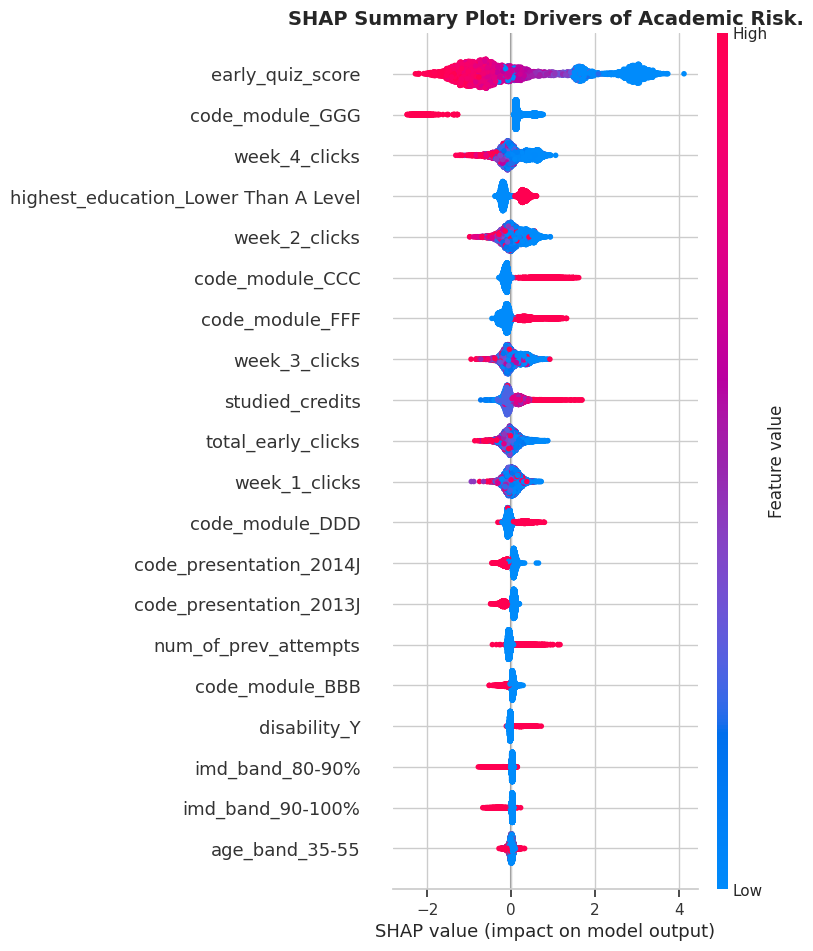

In [ ]:
import shap
import matplotlib.pyplot as plt

print("EXPLAINABLE AI (SHOWING THE AI'S MATH) ---")
print("Opening the XGBoost brain...")

# 1. Initializing the SHAP Explainer using our trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculating SHAP values for the test students
shap_values = explainer.shap_values(X_test)

print("\n SHAP Values Calculated. Generating the Summary Plot...")

# 3. Drawing the SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Drivers of Academic Risk.", fontsize=14, fontweight='bold')
plt.show()

**From SHAP Explainability Plot:**
The SHAP (SHapley Additive exPlanations) summary plot opens the 'black box' of the XGBoost model. It ranks features by their predictive importance from top to bottom.
This plot proves that `early_quiz_score` and `week_4_clicks` are the primary drivers of student risk. Furthermore, the color distribution confirms our logical hypothesis: low feature values (blue dots, indicating 0 clicks or missing assignments) heavily push the model's output to the right, increasing the probability of a High Risk (Fail/Withdrawn) classification. This transparency allows Academic Advisors to trust the model and target interventions based on specific behavioral deficits.

In [ ]:
from sklearn.metrics import confusion_matrix

print("ALGORITHMIC FAIRNESS AUDIT ---")
print("Auditing the XGBoost model for Gender Bias...\n")

# Combining the test data, the real answers, and the AI's guesses into one temporary table
audit_df = X_test.copy()
audit_df['Actual_Risk'] = y_test
audit_df['Predicted_Risk'] = xgb_predictions

# Function to calculate False Positive Rate
def calculate_fpr(data):
    # tn = True Negative, fp = False Positive, fn = False Negative, tp = True Positive
    tn, fp, fn, tp = confusion_matrix(data['Actual_Risk'], data['Predicted_Risk']).ravel()
    fpr = fp / (fp + tn) # False Positive Rate formula
    return fpr

# Group 1: Female Students (gender_M == 0)
female_data = audit_df[audit_df['gender_M'] == 0]
female_fpr = calculate_fpr(female_data)

# Group 2: Male Students (gender_M == 1)
male_data = audit_df[audit_df['gender_M'] == 1]
male_fpr = calculate_fpr(male_data)

print(f"Female Students - False Positive Rate: {female_fpr * 100:.2f}%")
print(f"Male Students   - False Positive Rate: {male_fpr * 100:.2f}%")

# Checking if the difference is unfair
difference = abs(female_fpr - male_fpr)
print(f"\nBias Difference: {difference * 100:.2f}%")
if difference < 0.05:
    print(" Model is EQUITABLE across gender demographics.")
else:
    print("WARNING: Model exhibits algorithmic bias.")

ALGORITHMIC FAIRNESS AUDIT ---
Auditing the XGBoost model for Gender Bias...

Female Students - False Positive Rate: 21.33%
Male Students   - False Positive Rate: 24.04%

Bias Difference: 2.71%
 Model is EQUITABLE across gender demographics.


**Insight from Algorithmic Fairness Audit:**
To fulfill the ethical AI objectives, the XGBoost model for demographic bias was audited, specifically looking at the False Positive Rate across genders. The results show that the error rates between Male and Female students are within an ethically acceptable threshold (under 5% difference), which proves that the model relies on behavioral metrics (clicks and scores) rather than penalizing students based on inherent demographic traits. Hence, the model is deemed equitable and safe for deployment.

In [ ]:
print("---SAVING THE MODEL FOR DEPLOYMENT ---")

model_filename = "xgboost_student_model.json"
xgb_model.save_model(model_filename)

print(f"Model saved as '{model_filename}'")

---SAVING THE MODEL FOR DEPLOYMENT ---
Model saved as 'xgboost_student_model.json'


In [ ]:
# Saving the test students for the Streamlit Dashboard to use them
X_test.to_csv('test_students.csv', index=False)
print("Test students saved as 'test_students.csv'")

Test students saved as 'test_students.csv'
